In [2]:
import pandas as pd
import sys
import matplotlib.pyplot as plt

In [3]:
def read_CSVs(algorithm,replicates):
    df_labeled = []
    for r in range(replicates):
        try:
            filename = f"profiles/{algorithm}/r{r}.csv"
            df = pd.read_csv(filename, index_col=False)
            if "eigen" in algorithm or "spectra" in algorithm:
                df[algorithm] = df[algorithm]/1000 # convert to seconds
            df["replicate"] = r
            df.rename(columns={"dim": "dimension"},errors="ignore",inplace=True)
            df_labeled.append(df)
        except:
            print(f"File {filename} not found. Skipping.")
            continue
    return pd.concat(df_labeled, ignore_index=True)


In [4]:
replicates = 100
algorithms = ["eigen.selfadjoint",
# "eigen.bdcsvd",
"eigen.eigensolver",
"spectra.dense.largest", # this one failed a lot
# "spectra.dense.smallest", # this one failed a lot
"spectra.inverse.smallest", # this one failed a lot
# "scipy.linalg.eigvals",
"scipy.linalg.eigvalsh",
"scipy.sparse.linalg.eigsh.largest",
# "scipy.sparse.linalg.eigs",   
# "scipy.sparse.linalg.eigs.smallest",
# "scipy.sparse.linalg.eigsh.smallest",
# "scipy.sparse.linalg.eigs.smallest.shifted",
"scipy.sparse.linalg.eigsh.smallest.shifted",
"scipy.sparse.linalg.eigsh.smallest.shifted.tol0"
]

In [5]:
dfs = []
for alg in algorithms:
    try:
        dfs.append(read_CSVs(alg, replicates))
    except:
        print(f"Error reading {alg}. Skipping.")
        continue
for df in dfs:
    # print(df["a"].unique())
    df["a"] = df["a"].round(2)
    df["b"] = df["b"].round(2)
    # print(df["a"].unique())
    df.set_index(["replicate","dimension","a","b","simplices"], inplace=True)


In [6]:
print(dfs)

[                                         eigen.selfadjoint  \
replicate dimension a    b    simplices                      
0         1         0.0  0.1  0                      0.000   
          2         0.0  0.1  0                      0.000   
          1         0.1  0.2  0                      0.000   
          2         0.1  0.2  0                      0.000   
          1         0.2  0.3  0                      0.000   
...                                                    ...   
99        2         9.8  9.9  2193                   4.069   
          1         9.9  10.0 1452                   0.513   
          2         9.9  10.0 2349                   4.881   
          1         10.0 10.1 1466                   0.439   
          2         10.0 10.1 2361                   4.611   

                                         eigen.selfadjoint_failed  
replicate dimension a    b    simplices                            
0         1         0.0  0.1  0                         

In [7]:
df = dfs[0].join(dfs[1:],how="left")
df.rename(columns={'scipy.sparse.linalg.eigsh': 'scipy.sparse.linalg.eigsh.largest'}, inplace=True)
cols = [c for c in df.columns if "_failed" not in c]
df = df[cols]

df

eigen.selfadjoint  eigen.eigensolver  \
replicate dimension a    b    simplices                                         
0         1         0.0  0.1  0                      0.000              0.000   
          2         0.0  0.1  0                      0.000              0.000   
          1         0.1  0.2  0                      0.000              0.000   
          2         0.1  0.2  0                      0.000              0.000   
          1         0.2  0.3  0                      0.000              0.000   
...                                                    ...                ...   
99        2         9.8  9.9  2193                   4.069             26.645   
          1         9.9  10.0 1452                   0.513              8.997   
          2         9.9  10.0 2349                   4.881             31.092   
          1         10.0 10.1 1466                   0.439              9.974   
          2         10.0 10.1 2361                   4.611             28.558   

                                         spectra.dense.largest  \
replicate dimension a    b    simplices                          
0         1         0.0  0.1  0                          0.000   
          2         0.0  0.1  0                          0.000   
          1         0.1  0.2  0                          0.000   
          2         0.1  0.2  0                          0.000   
          1         0.2  0.3  0                          0.000   
...                                                        ...   
99        2         9.8  9.9  2193                       0.212   
          1         9.9  10.0 1452                       0.020   
          2         9.9  10.0 2349                       0.288   
          1         10.0 10.1 1466                       0.022   
          2         10.0 10.1 2361                       0.203   

                                         spectra.inverse.smallest  \
replicate dimension a    b    simplices                             
0         1         0.0  0.1  0                             0.000   
          2         0.0  0.1  0                             0.000   
          1         0.1  0.2  0                             0.000   
          2         0.1  0.2  0                             0.000   
          1         0.2  0.3  0                             0.000   
...                                                           ...   
99        2         9.8  9.9  2193                          1.025   
          1         9.9  10.0 1452                          0.223   
          2         9.9  10.0 2349                          1.142   
          1         10.0 10.1 1466                          0.150   
          2         10.0 10.1 2361                          1.220   

                                         scipy.linalg.eigvalsh  \
replicate dimension a    b    simplices                          
0         1         0.0  0.1  0                       0.000000   
          2         0.0  0.1  0                       0.000000   
          1         0.1  0.2  0                       0.000000   
          2         0.1  0.2  0                       0.000000   
          1         0.2  0.3  0                       0.000000   
...                                                        ...   
99        2         9.8  9.9  2193                    1.547382   
          1         9.9  10.0 1452                    0.304040   
          2         9.9  10.0 2349                    1.857474   
          1         10.0 10.1 1466                    0.312670   
          2         10.0 10.1 2361                    1.838425   

                                         scipy.sparse.linalg.eigsh.largest  \
replicate dimension a    b    simplices                                      
0         1         0.0  0.1  0                                   0.000000   
          2         0.0  0.1  0                                   0.000000   
          1         0.1  0.2  0                            

In [8]:
nulls = df[df.isnull().any(axis=1)]
nulls

,,,,,eigen.selfadjoint,eigen.eigensolver,spectra.dense.largest,spectra.inverse.smallest,scipy.linalg.eigvalsh,scipy.sparse.linalg.eigsh.largest,scipy.sparse.linalg.eigsh.smallest.shifted,scipy.sparse.linalg.eigsh.smallest.shifted.tol0
replicate,dimension,a,b,simplices,,,,,,,,


In [9]:
print(nulls)

Empty DataFrame
Columns: [eigen.selfadjoint, eigen.eigensolver, spectra.dense.largest, spectra.inverse.smallest, scipy.linalg.eigvalsh, scipy.sparse.linalg.eigsh.largest, scipy.sparse.linalg.eigsh.smallest.shifted, scipy.sparse.linalg.eigsh.smallest.shifted.tol0]
Index: []


In [10]:
print(df)

                                         eigen.selfadjoint  eigen.eigensolver  \
replicate dimension a    b    simplices                                         
0         1         0.0  0.1  0                      0.000              0.000   
          2         0.0  0.1  0                      0.000              0.000   
          1         0.1  0.2  0                      0.000              0.000   
          2         0.1  0.2  0                      0.000              0.000   
          1         0.2  0.3  0                      0.000              0.000   
...                                                    ...                ...   
99        2         9.8  9.9  2193                   4.069             26.645   
          1         9.9  10.0 1452                   0.513              8.997   
          2         9.9  10.0 2349                   4.881             31.092   
          1         10.0 10.1 1466                   0.439              9.974   
          2         10.0 10.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [12]:
rc ={'figure.figsize': (6.5,5),
    'font.size':14,
}

sns.set_theme(style="whitegrid", font_scale=1.2,rc=rc)

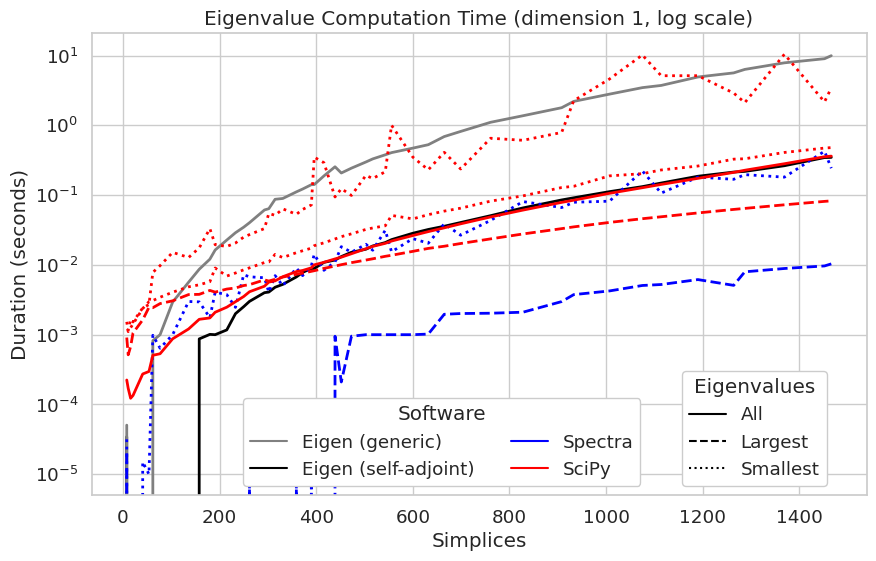

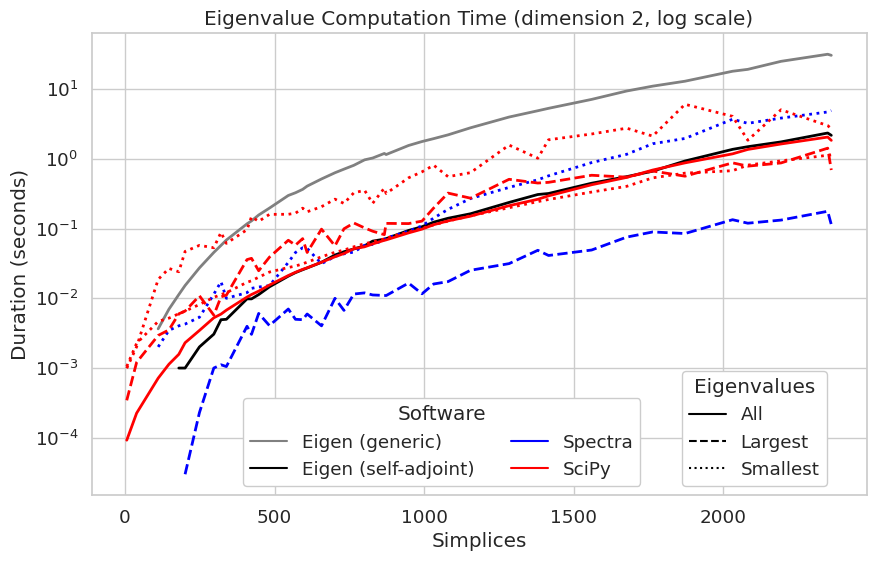

In [13]:
# df.groupby(["dimension","simplices","a","b"]).agg("mean")

dims = [1,2]
for d in dims:
    df_d = df[df.index.get_level_values("dimension") == d].groupby(["dimension","a","simplices"]).agg("mean")
    # print(df_d)
    plt.figure(figsize=(10,6))

    # fig, ax = plt.subplots(figsize=(10,6))
    for alg in algorithms:
        if "smallest" in alg:
            linestyle = ":"
        elif "largest" in alg:
            linestyle = "--"
        else:
            linestyle = "-"

        if "spectra" in alg:
            color = "blue"
        elif "eigen.selfadjoint" in alg:
            color = "black"
        elif "eigen.eigensolver" in alg:
            color = "grey"
        elif "scipy" in alg:
            color = "red"
        else:
            color = "green"

        ydata = df_d[alg].values
        xdata = df_d.index.get_level_values("simplices").values
        nonzero_idx = (ydata > 0).nonzero()[0]
        start = nonzero_idx[0]

        xdata = xdata[start:]
        ydata = ydata[start:]
        try:
            ax = sns.lineplot(x=xdata,y=ydata,label=None, linewidth=2,linestyle=linestyle, color=color, errorbar=None)
            # ax.plot(xdata, ydata, label=alg,marker=None,linestyle=linestyle,color=color)

            # ax.plot(df_d.index.get_level_values("simplices"),df_d[alg], label=alg,marker=None,linestyle=linestyle,color=color)
        except:
            print(f"Error plotting {alg}. Skipping.")
            continue
    
    plt.xlabel("Simplices")
    plt.ylabel("Duration (seconds)")
    plt.title(f"Eigenvalue Computation Time (dimension {d}, log scale)")
    plt.yscale("log")
    # plt.ylim((1e-3,1e3))

    spectrum_lines = [
        Line2D([0], [0], color="black", linestyle="-", label="All"),
        Line2D([0], [0], color="black", linestyle="--", label="Largest"),
        Line2D([0], [0], color="black", linestyle=":", label="Smallest")
    ]
    software_legend = [
        Line2D([0], [0], color='grey', linestyle='-', label='Eigen (generic)'),
        Line2D([0], [0], color='black', linestyle='-', label='Eigen (self-adjoint)'),
        Line2D([0], [0], color='blue', linestyle='-', label='Spectra'),
        Line2D([0], [0], color='red', linestyle='-', label='SciPy')
    ]
    # upper right, bbox_to_anchor=(0.65,0.3) and other "lower right" no bbox was close

    first_legend = plt.legend(handles=software_legend,ncols=2,loc='lower right',title="Software", bbox_to_anchor=(0.72,0.0), frameon=True, framealpha=1.0)  # algorithm legend
    plt.gca().add_artist(first_legend)
    plt.legend(handles=spectrum_lines, loc='lower left', title='Eigenvalues', bbox_to_anchor=(0.75,0.0), frameon=True, framealpha=1.0)
    # plt.savefig(f"eigenvalue_algorithms_torus_d{d}.png", dpi=600, bbox_inches="tight")
    plt.show()

,0
eigen.selfadjoint,23.913650
eigen.eigensolver,388.130390
spectra.dense.largest,2.053390
spectra.inverse.smallest,45.617800
scipy.linalg.eigvalsh,22.276307
scipy.sparse.linalg.eigsh.largest,17.275887
scipy.sparse.linalg.eigsh.smallest.shifted,18.698065
scipy.sparse.linalg.eigsh.smallest.shifted.tol0,151.433504


In [15]:
total_durations = pd.DataFrame(df.groupby(["dimension","simplices","a","b"]).agg("mean").sum())
total_durations.columns = ["time"]
print(type(total_durations))
total_durations["rank"] = total_durations.rank()

final = total_durations.sort_values(by="rank",ascending=False)
final.reset_index()
print(final)

<class 'pandas.core.frame.DataFrame'>
                                                       time  rank
eigen.eigensolver                                388.130390   8.0
scipy.sparse.linalg.eigsh.smallest.shifted.tol0  151.433504   7.0
spectra.inverse.smallest                          45.617800   6.0
eigen.selfadjoint                                 23.913650   5.0
scipy.linalg.eigvalsh                             22.276307   4.0
scipy.sparse.linalg.eigsh.smallest.shifted        18.698065   3.0
scipy.sparse.linalg.eigsh.largest                 17.275887   2.0
spectra.dense.largest                              2.053390   1.0


In [36]:
relative = final.copy()
for idx in relative.index:
    
    # print(relative["time"][idx])
    relative[idx] = relative["time"][idx]/relative["time"]
pretty_names = {
    "scipy.sparse.linalg.eigsh.largest": "Scipy (largest)",
    "scipy.sparse.linalg.eigsh.smallest.shifted": "Scipy (smallest, $\\verb|tol|=10^{-6}$)",
    "scipy.sparse.linalg.eigsh.smallest.shifted.tol0": "SciPy (smallest, $\\verb|tol|=\\epsilon$)",
    "spectra.dense.largest": "Spectra (largest)",
    "spectra.inverse.smallest": "Spectra (smallest)",
    "scipy.linalg.eigvalsh": "Scipy (all)",
    "eigen.selfadjoint": "Eigen (self-adjoint, all)",
    "eigen.eigensolver": "Eigen (generic, all)",
}
relative.drop(inplace=True, columns=["scipy.sparse.linalg.eigsh.smallest.shifted"])
relative.rename(inplace=True, columns=pretty_names)
relative.rename(inplace=True,index=pretty_names)
relative

,time,rank,"Eigen (generic, all)","SciPy (smallest, $\verb|tol|=\epsilon$)",Spectra (smallest),"Eigen (self-adjoint, all)",Scipy (all),Scipy (largest),Spectra (largest)
"Eigen (generic, all)",388.130390,8.0,1.000000,0.390161,0.117532,0.061612,0.057394,0.044511,0.005290
"SciPy (smallest, $\verb|tol|=\epsilon$)",151.433504,7.0,2.563042,1.000000,0.301240,0.157915,0.147103,0.114082,0.013560
Spectra (smallest),45.617800,6.0,8.508310,3.319614,1.000000,0.524218,0.488325,0.378709,0.045013
"Eigen (self-adjoint, all)",23.913650,5.0,16.230496,6.332513,1.907605,1.000000,0.931531,0.722428,0.085867
Scipy (all),22.276307,4.0,17.423462,6.797963,2.047817,1.073502,1.000000,0.775527,0.092178
"Scipy (smallest, $\verb|tol|=10^{-6}$)",18.698065,3.0,20.757784,8.098886,2.439707,1.278937,1.191370,0.923940,0.109818
Scipy (largest),17.275887,2.0,22.466597,8.765599,2.640547,1.384221,1.289445,1.000000,0.118859
Spectra (largest),2.053390,1.0,189.019324,73.748048,22.215848,11.645937,10.848551,8.413349,1.000000


In [37]:
to_print = relative.copy()
to_print.drop(inplace=True,columns=["rank", "Scipy (all)", "Spectra (smallest)", "Spectra (largest)", "Scipy (largest)"])
to_print.columns = pd.MultiIndex.from_product([["Speedup Over"], to_print.columns])
latex_output = to_print.to_latex(float_format="%.1f",multicolumn=True,multicolumn_format='c')
print(latex_output)

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{4}{c}{Speedup Over} \\
 & time & Eigen (generic, all) & SciPy (smallest, $\verb|tol|=\epsilon$) & Eigen (self-adjoint, all) \\
\midrule
Eigen (generic, all) & 388.1 & 1.0 & 0.4 & 0.1 \\
SciPy (smallest, $\verb|tol|=\epsilon$) & 151.4 & 2.6 & 1.0 & 0.2 \\
Spectra (smallest) & 45.6 & 8.5 & 3.3 & 0.5 \\
Eigen (self-adjoint, all) & 23.9 & 16.2 & 6.3 & 1.0 \\
Scipy (all) & 22.3 & 17.4 & 6.8 & 1.1 \\
Scipy (smallest, $\verb|tol|=10^{-6}$) & 18.7 & 20.8 & 8.1 & 1.3 \\
Scipy (largest) & 17.3 & 22.5 & 8.8 & 1.4 \\
Spectra (largest) & 2.1 & 189.0 & 73.7 & 11.6 \\
\bottomrule
\end{tabular}



In [40]:
import scipy
import numpy as np
from scipy.io import mmread
import time
import timeit
import pandas as pd
import sys

def get_filtrations(delta):
    start = 0.0
    end = 10.0
    filtrations = [start+i*delta for i in range(int((end-start)/delta) + 1)]
    return filtrations

def print_ref_eigs():
        filtrations = get_filtrations(delta=0.1)
        dims = [2]
        
        ref_eigs = [[],#dim 0
                        [],#dim 1
                        []]#dim 2
        for filtration in filtrations:
                for dim in dims:
                        filename = f"./protein_L/dim{dim}_a{filtration:.2f}_b{filtration+0.1:.2f}.mkt"

                        L = mmread(filename)
                        # print("Type L: ", type(L))
                        time_start = time.time()
                        eigs = scipy.linalg.eigvalsh(L.todense())
                        time_spectra = time.time() - time_start
                        print(f"d{dim}, a{filtration}, t{time_spectra:.2f}, Last 10 eigs: ", eigs[-10:])

In [41]:
print_ref_eigs()

d2, a0.0, t0.00, Last 10 eigs:  []
d2, a0.1, t0.00, Last 10 eigs:  []
d2, a0.2, t0.00, Last 10 eigs:  []
d2, a0.30000000000000004, t0.00, Last 10 eigs:  []
d2, a0.4, t0.00, Last 10 eigs:  []
d2, a0.5, t0.00, Last 10 eigs:  []
d2, a0.6000000000000001, t0.00, Last 10 eigs:  []
d2, a0.7000000000000001, t0.00, Last 10 eigs:  []
d2, a0.8, t0.00, Last 10 eigs:  []
d2, a0.9, t0.00, Last 10 eigs:  []
d2, a1.0, t0.00, Last 10 eigs:  []
d2, a1.1, t0.00, Last 10 eigs:  []
d2, a1.2000000000000002, t0.00, Last 10 eigs:  []
d2, a1.3, t0.00, Last 10 eigs:  []
d2, a1.4000000000000001, t0.00, Last 10 eigs:  []
d2, a1.5, t0.00, Last 10 eigs:  []
d2, a1.6, t0.00, Last 10 eigs:  []
d2, a1.7000000000000002, t0.00, Last 10 eigs:  []
d2, a1.8, t0.00, Last 10 eigs:  []
d2, a1.9000000000000001, t0.00, Last 10 eigs:  []
d2, a2.0, t0.00, Last 10 eigs:  []
d2, a2.1, t0.00, Last 10 eigs:  []
d2, a2.2, t0.00, Last 10 eigs:  []
d2, a2.3000000000000003, t0.00, Last 10 eigs:  []
d2, a2.4000000000000004, t0.00, Last 10

KeyboardInterrupt: 